In [1]:
import os
import sys
import dotenv

dotenv.load_dotenv()

# hugging face api key
HF_API_KEY = os.getenv("HF_API_KEY")
if HF_API_KEY is None:
    print("Error: HF_API_KEY environment variable not set.")
    sys.exit(1)

In [2]:
from pathlib import Path
import pandas as pd
import torch

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root()
A1_DIR = REPO_ROOT / "deliverables-solutions" / "Assignments" / "outputs" / "M01_A_sol"
A2_DIR = REPO_ROOT / "deliverables-solutions" / "Assignments" / "outputs" / "M02_A_sol"
A3_DIR = REPO_ROOT / "deliverables-solutions" / "Assignments" / "outputs" / "M04_A_sol"
A3_DIR.mkdir(parents=True, exist_ok=True)

# Google Drive version kept here as comments for future Colab use.
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)
# A1_DIR = Path("/content/drive/MyDrive/assignment01")
# A2_DIR = Path("/content/drive/MyDrive/assignment02")
# A3_DIR = Path("/content/drive/MyDrive/assignment03")
# A3_DIR.mkdir(parents=True, exist_ok=True)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

chunks_df = pd.read_csv(A1_DIR / "chunks.csv")
print(chunks_df.shape)
chunks_df.info()
chunks_df.describe(include="all")
chunks_df.head()

companies = chunks_df["company"].dropna().unique().tolist()
tickers = chunks_df[["company", "ticker"]].drop_duplicates().set_index("company")["ticker"].to_dict()
company_a, company_b = companies[:2]
ticker_a, ticker_b = tickers[company_a], tickers[company_b]
print("Companies:", company_a, "vs.", company_b)

# Keep the assignment scope to exactly two rival companies.
# If you changed M01's company list, rerun M01 and this cell will pick up that order.
chunks_df = chunks_df[chunks_df["company"].isin([company_a, company_b])].copy()
print(f"Filtered to two-company assignment scope: {len(chunks_df):,} chunks")


GPU available: True
Device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
(4525, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   chunk_id      4525 non-null   str  
 1   company       4525 non-null   str  
 2   ticker        4525 non-null   str  
 3   naics_code    4525 non-null   int64
 4   year          4525 non-null   int64
 5   item          4525 non-null   str  
 6   chunk_number  4525 non-null   int64
 7   chunk_text    4525 non-null   str  
 8   char_count    4525 non-null   int64
dtypes: int64(4), str(5)
memory usage: 4.0 MB
Companies: Microsoft vs. Oracle
Filtered to two-company assignment scope: 4,525 chunks


📊 **Required:** Bar chart of chunk counts per company and per item type.

# BERT Attention Visualization {#sec-attention}

## Load BERT and Extract Attention


In [3]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
bert.eval()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Select one matched sentence pair — one sentence from Company A's Item 7 or Item 7A and one topically similar sentence from Company B's matching section (same financial-performance or market-risk topic, different wording). Each sentence should be 15–30 tokens.


In [4]:
import re

## clean punctuations, and words below 3 or above 15 characters, to improve readability of attention heatmaps
def pick_attention_sentence(company: str, item_priority=("7A", "7", "8")) -> str:
    """Pick a readable 15-30 token sentence from the saved M01 chunks."""
    for item in item_priority:
        candidates = chunks_df[(chunks_df["company"] == company) & (chunks_df["item"] == item)]
        for text in candidates["chunk_text"].dropna().head(75):
            for sentence in re.split(r"(?<=[.!?])\s+", text):
                cleaned = re.sub(r"\s+", " ", sentence).strip()
                cleaned = re.sub(r"[^\w\s]", "", cleaned)  # Remove punctuation
                cleaned = re.sub(r"\b\w{1,2}\b", "", cleaned)  # Remove words with less than 3 characters
                cleaned = re.sub(r"\b\w{16,}\b", "", cleaned)  # Remove words with more than 15 characters
                # remove extra spaces again after cleaning
                cleaned = re.sub(r"\s+", " ", cleaned).strip()
                # remove (special charecters) and numbers
                cleaned = re.sub(r"[\(\)\d]", "", cleaned)
                # remove words with (special characters and numbers, ##***) and words with less than 4 characters again after cleaning
                cleaned = re.sub(r"\b\w{1,3}\b", "", cleaned)
                token_count = len(cleaned.split())
                if 15 <= token_count <= 30:
                    return cleaned
    raise ValueError(f"Could not find a 15-30 token sentence for {company}.")


sentence_a = pick_attention_sentence(company_a)
sentence_b = pick_attention_sentence(company_b)
print(company_a, ":", sentence_a)
print(company_b, ":", sentence_b)


def get_attention(sentence: str):
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = bert(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return outputs.attentions, tokens


attn_a, tokens_a = get_attention(sentence_a)
attn_b, tokens_b = get_attention(sentence_b)


Microsoft : BUSINESS GENERAL Embracing  Future Microsoft technology company whose mission empower every person  every organization  planet achieve more
Oracle : Quantitative  Qualitative Disclosures About Market Risk Cash Cash Equivalents Marketable Securities  Interest Income Risk Cash cash equivalents  marketable securities were  billion   billion     respectively


Build a DataFrame of top-attended tokens for Company A (Layer 12, Head 1):


In [5]:
import numpy as np

weights = attn_a[11][0, 0].detach().numpy()   # Layer 12, Head 1
top_idx = np.argsort(weights.mean(axis=0))[::-1][:10]

attention_df = pd.DataFrame({
    "token": [tokens_a[i] for i in top_idx],
    "mean_attention": weights.mean(axis=0)[top_idx]
})
print(attention_df.shape)
attention_df.info()
attention_df.describe()
attention_df.head(10)


(10, 2)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   token           10 non-null     str    
 1   mean_attention  10 non-null     float32
dtypes: float32(1), str(1)
memory usage: 329.0 bytes


,token,mean_attention
0,[SEP],0.842692
1,[CLS],0.025017
2,technology,0.021397
3,microsoft,0.020821
4,organization,0.015453
5,embracing,0.009394
6,company,0.009024
7,mission,0.008097
8,planet,0.006300
9,##power,0.005598


## Plot Attention Heatmaps

Plot four heatmaps: Company A (Layer 1, Head 1), Company A (Layer 12, Head 1), Company B (Layer 1, Head 1), Company B (Layer 12, Head 1).


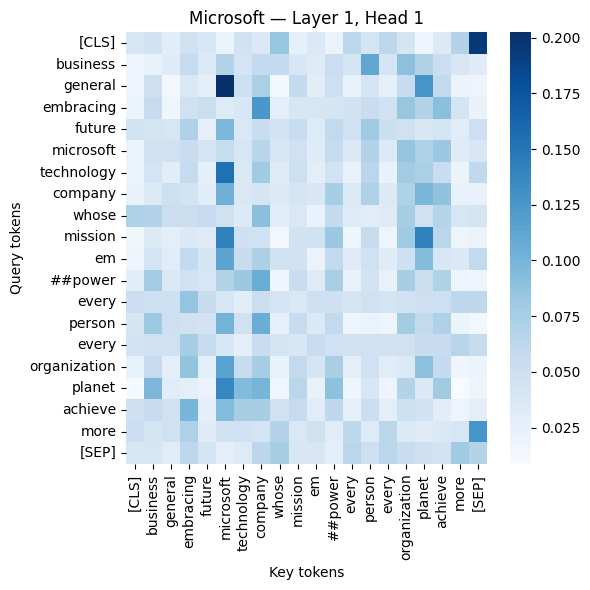

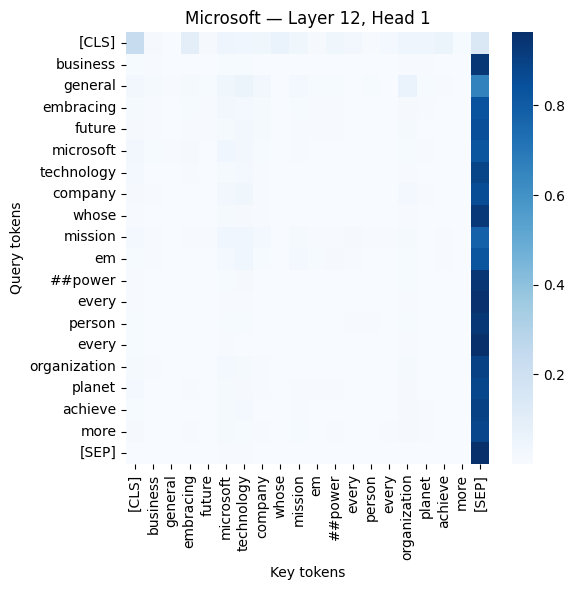

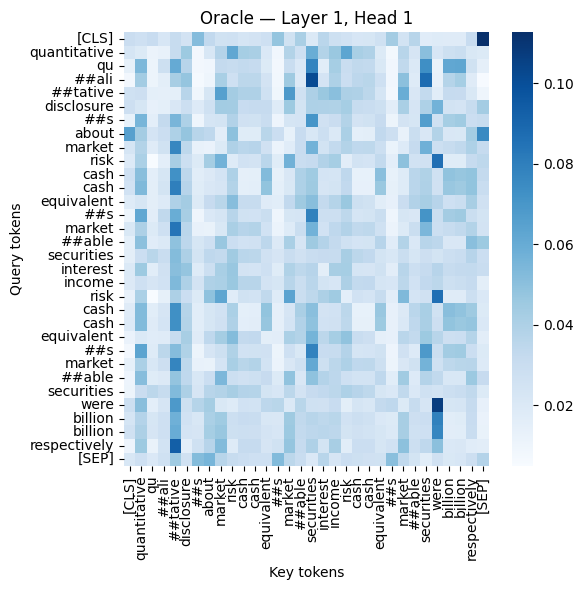

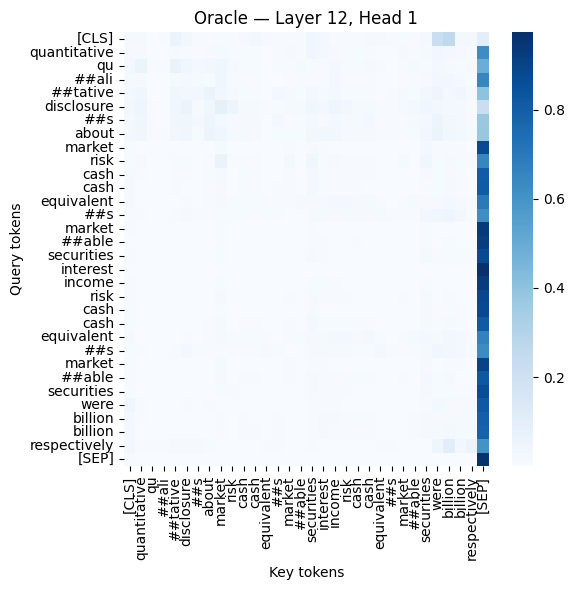

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_attention_heatmap(attn, tokens, layer: int, head: int, title: str):
    weights = attn[layer][0, head].detach().numpy()
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(weights, xticklabels=tokens, yticklabels=tokens,
                cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Key tokens")
    ax.set_ylabel("Query tokens")
    plt.tight_layout()
    plt.show()

plot_attention_heatmap(attn_a, tokens_a, layer=0, head=0,
                       title=f"{company_a} — Layer 1, Head 1")
plot_attention_heatmap(attn_a, tokens_a, layer=11, head=0,
                       title=f"{company_a} — Layer 12, Head 1")
plot_attention_heatmap(attn_b, tokens_b, layer=0, head=0,
                       title=f"{company_b} — Layer 1, Head 1")
plot_attention_heatmap(attn_b, tokens_b, layer=11, head=0,
                       title=f"{company_b} — Layer 12, Head 1")


📊 **Required:** All four heatmaps with token labels on both axes.

# BERT Fine-Tuned Classifier {#sec-bert-cls}

## Add a Classification Head (Frozen Encoder)

Freeze the BERT encoder. Add a single Linear layer on top of the `[CLS]` token embedding.


In [7]:
class BERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, num_classes: int = 2):
        super().__init__()
        self.bert = bert_model
        for param in self.bert.parameters():
            param.requires_grad = False   # freeze encoder
        self.classifier = torch.nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls)


Tokenize all chunks (truncate to 128 tokens). Train for 3 epochs with AdamW optimizer.

## Evaluate


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred,
      target_names=[company_b, company_a]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=[company_b, company_a],
            yticklabels=[company_b, company_a],
            cmap="Blues")
plt.title("BERT Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


NameError: name 'y_true' is not defined

📊 **Required:** Confusion matrix heatmap with company names on axes.

Save classification head weights:


In [ ]:
torch.save(bert_clf.classifier.state_dict(), A3_DIR / "bert_classifier_weights.pt")


# GPT-2 Perplexity Analysis {#sec-gpt2}

## Compute Perplexity Per Chunk

GPT-2 is a **decoder-only** model that predicts each token given only the tokens to its left. Perplexity measures how surprised the model is by a text: **lower perplexity = more standard, predictable language; higher perplexity = more unusual, distinctive language**.


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import math

gpt2_tok = GPT2Tokenizer.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2.eval()

def compute_perplexity(text: str, max_length: int = 512) -> float:
    enc = gpt2_tok(text, return_tensors="pt",
                   truncation=True, max_length=max_length)
    with torch.no_grad():
        out = gpt2(**enc, labels=enc["input_ids"])
    return math.exp(out.loss.item())


Sample 50 chunks per company per item type. Compute perplexity for each.


In [ ]:
ppl_records = []
for _, row in sample_chunks.iterrows():
    ppl = compute_perplexity(row["chunk_text"])
    ppl_records.append({
        "company": row["company"],
        "item": row["item"],
        "perplexity": ppl
    })

ppl_df = pd.DataFrame(ppl_records)
print(ppl_df.shape)
ppl_df.info()
ppl_df.describe()
ppl_df.head()


📊 **Required:** Box plot of perplexity by company, with a second panel by item type (Item 7 vs Item 7A vs Item 8).

Save:


In [ ]:
ppl_df.to_csv(A3_DIR / "ppl_df.csv", index=False)


## GPT-2 Completion Examples

Take the first 20 tokens of one distinctive risk-factor sentence from each company. Show the top-5 beam-search continuations:


In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2",
                     max_new_tokens=30, num_return_sequences=5,
                     num_beams=5, do_sample=False)

completions_a = generator(prompt_a)
completions_b = generator(prompt_b)

comp_df = pd.DataFrame({
    "#": range(1, 6),
    f"{company_a} continuation": [c["generated_text"] for c in completions_a],
    f"{company_b} continuation": [c["generated_text"] for c in completions_b]
})
comp_df


# Yahoo Finance Risk Metrics {#sec-yahoo}

Pull 3-year beta and 52-week return for both companies:


In [ ]:
import yfinance as yf

def get_risk_metrics(ticker: str) -> dict:
    info = yf.Ticker(ticker).info
    hist = yf.Ticker(ticker).history(period="1y")
    annual_return = (hist["Close"].iloc[-1] / hist["Close"].iloc[0]) - 1
    return {
        "ticker": ticker,
        "beta": info.get("beta"),
        "trailingPE": info.get("trailingPE"),
        "52w_return": round(annual_return, 4),
        "marketCap": info.get("marketCap")
    }

risk_df = pd.DataFrame([get_risk_metrics(ticker_a), get_risk_metrics(ticker_b)])
print(risk_df.shape)
risk_df.info()
risk_df.describe()
risk_df


📊 **Required:** Show this table in your Word document. You will use beta and return in Q3 and Q4.

# 4-Method Accuracy Comparison {#sec-compare}

Compile all accuracy results into one comparison table. Fill in A1 and A2 values from prior assignments.


In [ ]:
comparison_df = pd.DataFrame({
    "Assignment": ["A1", "A1", "A2", "A2", "A3"],
    "Method": [
        "TF-IDF BoW (Linear)",
        "Cosine Similarity Baseline",
        "Word2Vec MLP (scratch)",
        "GloVe MLP (pretrained)",
        "BERT (frozen encoder + linear head)"
    ],
    "Accuracy": [a1_bow, a1_cos, a2_w2v, a2_glove, a3_bert]
})
print(comparison_df)


📊 **Required:** Horizontal bar chart of all five methods sorted by accuracy.

# Q1: Which Attention Layer Focuses on More Meaningful Tokens? {#sec-q1}

Refer to your four attention heatmaps (Layer 1 and Layer 12 for each company).

**Answer in your Word document:** For each company, describe what changes from Layer 1 to Layer 12 attention patterns. Does later-layer attention focus on more financially meaningful tokens? Give at least two specific token examples from your heatmaps and explain why the shift is consistent (or inconsistent) with BERT's architecture.

# Q2: How Much Does BERT Improve Over Word2Vec? {#sec-q2}

Refer to the 4-method accuracy comparison table.

**Answer in your Word document:** Report the accuracy gap between BERT (A3) and the best A2 method. Estimate the difference in compute time and model size (parameter count) between the two approaches. Given those tradeoffs, under what business conditions would you recommend BERT over GloVe for a financial NLP classification task?


# Q3: What Does Perplexity Reveal About Company Writing Style? {#sec-q3}

Refer to your GPT-2 perplexity box plot and your Yahoo Finance risk metrics table.

**Answer in your Word document:** Which company has higher average GPT-2 perplexity? What does this mean about how standard or distinctive their 10-K language is? Does the company with higher perplexity also have higher beta in the Yahoo Finance table — suggesting that more unusual language correlates with more unpredictable market behavior? State clearly whether you observe this pattern or not, and why it might or might not hold.

# Q4: Which Method Would You Recommend to a FinTech Compliance Team? {#sec-q4}

## Business Recommendation — Model Selection

A FinTech compliance team needs to flag unusual risk language in 500 new 10-K filings per quarter on a **$5,000/quarter cloud budget**.

**Answer in your Word document (≤1 page):** Which of the five methods in your comparison table would you recommend? Your answer must explicitly reference:

- At least two accuracy values from the comparison table
- Estimated compute cost or processing time (rough order of magnitude)
- The interpretability vs. accuracy tradeoff
- Whether the beta and P/E profile of your two rivals changes your recommendation (e.g., would you use a more expensive model for a higher-beta company?)

# Deliverables Summary {.unnumbered}

| Artifact | Location |
|----------|----------|
| `bert_classifier_weights.pt` | `/assignment03/` on Drive |
| `ppl_df.csv` | `/assignment03/` on Drive |
| 4 attention heatmap figures | In notebook + Word doc |
| GPT-2 perplexity box plot | In notebook + Word doc |
| GPT-2 completion table | In notebook + Word doc |
| 4-method accuracy comparison table | In notebook + Word doc |
| Yahoo Finance risk metrics table | In notebook + Word doc |
| AI disclosure document | Blackboard submission |

# Use of Generative AI {.unnumbered}

You may use generative AI tools for code assistance, debugging, and explanation. You must:

- List every tool used
- State exactly which task each tool supported
- Include the complete prompt and the corresponding output excerpt or exported response, not only a one-line summary
- Include a shared conversation link when the tool supports sharing; if it does not, say so explicitly
- Identify which AI-generated outputs were used in the final submission and which were discarded or corrected
- Explain how you validated the output against notebook execution, saved artifacts, and manual inspection

When possible, preserve the original interaction using a share link or export feature. Examples include:

- **Gemini:** export the response to Google Docs or share the chat if available
- **ChatGPT:** submit a ChatGPT shared link
- **Claude:** submit a Claude shared chat link
- **Perplexity:** submit a shared thread link

If a share link is not available, include the full prompt and the relevant output in the disclosure document as screenshots or copied text.

Your AI disclosure should include the following fields:

1. Tool name and provider
2. Date used
3. Task supported
4. Complete prompt(s)
5. Share link(s), if available
6. Output excerpt(s) or exported response used in final submission
7. Validation steps you performed
8. Corrections you made after validation

Submit AI disclosure as a separate document. Generic statements such as "I used AI for help" are not sufficient for full credit.
